In [2]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [3]:
!pip install shap

You should consider upgrading via the '/home/venkatesh/.pyenv/versions/3.9.7/bin/python3.9 -m pip install --upgrade pip' command.


In [4]:
import sys
print(sys.executable)  # just to confirm it's miniconda3/bin/python
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install shap


/home/venkatesh/miniconda3/bin/python


In [5]:
import shap
print(shap.__version__)


0.50.0


/home/venkatesh/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 0. Imports and basic setup


In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.inspection import PartialDependenceDisplay

import shap
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


# 1. Load the merged 2023 data

In [7]:

df = pd.read_csv("./final_df.csv")

print("Shape:", df.shape)
df.head()


/tmp/ipykernel_2326/1539753984.py:1: DtypeWarning: Columns (35,36,55,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("./final_df.csv")


Shape: (92400, 141)


,ST_CASE,VEH_NO,PER_NO,MAKE,BODY_TYP,ROLLOVER,AGE,AGENAME,SEXNAME,PER_TYPNAME,INJ_SEVNAME,SEAT_POSNAME,REST_USENAME,REST_MISNAME,HELM_USENAME,HELM_MISNAME,AIR_BAGNAME,EJECTIONNAME,EJ_PATHNAME,EXTRICATNAME,DRINKINGNAME,ALC_STATUSNAME,ATST_TYPNAME,ALC_RESNAME,DRUGSNAME,DSTATUS,DSTATUSNAME,HOSPITALNAME,DOANAME,DEATH_MONAME,DEATH_DANAME,DEATH_YRNAME,DEATH_TMNAME,DEATH_HRNAME,DEATH_MNNAME,DEVTYPENAME,DEVMOTORNAME,LOCATIONNAME,WORK_INJNAME,HISPANICNAME,STATENAME,PEDS,PERNOTMVIT,VE_TOTAL,VE_FORMS,PVH_INVL,PERSONS,PERMVIT,COUNTYNAME,CITYNAME,MONTHNAME,DAYNAME,DAY_WEEKNAME,YEAR,HOURNAME,MINUTENAME,ROUTENAME,RUR_URBNAME,FUNC_SYSNAME,RD_OWNERNAME,NHSNAME,SP_JURNAME,HARM_EVNAME,MAN_COLLNAME,RELJCT1NAME,RELJCT2NAME,TYP_INTNAME,REL_ROADNAME,WRK_ZONENAME,LGT_CONDNAME,WEATHERNAME,SCH_BUSNAME,RAILNAME,FATALS,NUMOCCSNAME,UNITTYPENAME,HIT_RUNNAME,REG_STATNAME,OWNERNAME,MOD_YEARNAME,VPICMAKENAME,VPICMODELNAME,VPICBODYCLASSNAME,MAKENAME,BODY_TYPNAME,ICFINALBODYNAME,GVWR_FROMNAME,GVWR_TONAME,TOW_VEHNAME,V_CONFIGNAME,TRAV_SPNAME,ROLLOVERNAME,ROLINLOCNAME,IMPACT1NAME,DEFORMEDNAME,TOWEDNAME,M_HARMNAME,FIRE_EXPNAME,DR_DRINKNAME,DR_PRESNAME,L_STATENAME,DR_ZIP,DR_ZIPNAME,L_TYPENAME,L_STATUSNAME,CDL_STATNAME,L_ENDORSNAME,L_COMPLNAME,L_RESTRINAME,DR_HGTNAME,DR_WGTNAME,PREV_ACCNAME,PREV_SUS1NAME,PREV_SUS2NAME,PREV_SUS3NAME,PREV_DWINAME,PREV_SPDNAME,PREV_OTHNAME,FIRST_MONAME,FIRST_YRNAME,LAST_MONAME,LAST_YRNAME,SPEEDRELNAME,VTRAFWAYNAME,VNUM_LANNAME,VSPD_LIMNAME,VALIGNNAME,VPROFILENAME,VPAVETYPNAME,VSURCONDNAME,VTRAFCONNAME,P_CRASH1NAME,P_CRASH2NAME,P_CRASH3NAME,PCRASH4NAME,PCRASH5NAME,ACC_TYPENAME,ACC_CONFIGNAME,MODEL,DEATHS,PERSON_SOURCE
0,10001,1,1,12.0,14.0,3.0,33,33 Years,Male,Driver of a Motor Vehicle In-Transport,Fatal Injury (K),"Front Seat, Left Side",Shoulder and Lap Belt Used,No Indication of Misuse,Not Applicable,None Used/Not Applicable,Deployed- Front,Not Ejected,Ejection Path Not Applicable,Not Extricated or Not Applicable,No (Alcohol Not Involved),Test Not Given,Test Not Given,Test Not Given,No (drugs not involved),0,Test Not Given,Not Transported for Treatment,Died at Scene,January,4,2023,2220,22:00-22:59,20,NaN,NaN,Occupant of a Motor Vehicle,No,Non-Hispanic,Alabama,0.0,0.0,1.0,1.0,0.0,1.0,1.0,BUTLER (13),NOT APPLICABLE,January,4.0,Wednesday,2023.0,10:00pm-10:59pm,20,U.S. Highway,Rural,Major Collector,State Highway Agency,This Section IS NOT on the NHS,No Special Jurisdiction,Rollover/Overturn,The First Harmful Event was Not a Collision wi...,No,Non-Junction,Not an Intersection,On Roadside,NaN,Dark - Not Lighted,Clear,No,Not Applicable,1.0,01,Motor Vehicle In-Transport (Inside or Outside ...,No,Alabama,Driver (in this crash) Not Registered Owner (O...,1996,Ford,Explorer,Sport Utility Vehicle (SUV)/Multi-Purpose Vehi...,Ford,"Compact Utility (Utility Vehicle Categories ""S...",Not Applicable,"Class 1: 6,000 lbs. or less (2,722 kg or less)","Class 1: 6,000 lbs. or less (2,722 kg or less)",No Trailers,Not Applicable,055 MPH,Rollover,On Roadside,Non-Collision,Disabling Damage,Towed,Embankment,No or Not Reported,No,Yes,Georgia,36069.0,36069,Full Driver License,Valid,No (CDL),No Endorsements required for this vehicle,Valid license for this class vehicle,No Restrictions or Not Applicable,Unknown,Unknown,NaN,NaN,NaN,NaN,NaN,1,NaN,November,2022,November,2022,No,"Two-Way, Not Divided",Two lanes,55 MPH,Straight,Downhill,"Blacktop, Bituminous, or Asphalt",Dry,No Controls,Going Straight,Off the edge of the road on the right side,Steering left,Skidding laterally clockwise rotation,Departed roadway,A2-Single Driver-Right Roadside Departure-Cont...,Single Driver-Right Roadside Departure,401.0,1.0,vehicle-linked
1,10002,1,1,7.0,5.0,0.0,32,32 Years,Female,Driver of a Motor Vehicle In-Transport,Fatal Injury (K),"Front Seat, Left Side",None Used/Not Applicable,None Used/Not Applicable,Not Applicable,None Used/Not Applicable,Deployed- Front,Not Ejected,Ejection Path Not Applicable,Not Extricated or Not Applicable,Yes (Alcohol Involved),Test Given,Blood,0.217 % 

# 2. Filter to drivers and define the multi-class injury target

# 2.1 Filter to driver rows

In [8]:
df["PER_TYPNAME"].value_counts().head(20)

PER_TYPNAME
Driver of a Motor Vehicle In-Transport                    57939
Passenger of a Motor Vehicle In-Transport                 24658
Pedestrian                                                 7730
Bicyclist                                                  1191
Occupant of a Motor Vehicle Not In- Transport               456
Person on a Personal Conveyance                             244
Occupant of a Non-Motor Vehicle Transport Device             68
Unknown Occupant Type in a Motor Vehicle In- Transport       60
Person In/On a Building                                      42
Other Pedalcyclist                                           12
Name: count, dtype: int64

In [9]:
driver_mask = df["PER_TYPNAME"].str.contains("Driver", case=False, na=False)
drivers = df[driver_mask].copy()

drivers.shape, drivers["PER_TYPNAME"].value_counts()


((57939, 141),
 PER_TYPNAME
 Driver of a Motor Vehicle In-Transport    57939
 Name: count, dtype: int64)

# 2.2 Define injury severity classes

In [10]:
drivers["INJ_SEVNAME"].value_counts()

INJ_SEVNAME
Fatal Injury (K)                25578
No Apparent Injury (O)          17242
Suspected Minor Injury (B)       5326
Suspected Serious Injury (A)     4687
Possible Injury (C)              3764
Unknown/Not Reported             1230
Injured, Severity Unknown         110
Died Prior to Crash                 2
Name: count, dtype: int64

In [11]:
severity_map = {
    "No Apparent Injury (O)": 0,
    "Possible Injury (C)": 1,
    "Suspected Minor Injury (B)": 1,   # merge possible/minor
    "Suspected Serious Injury (A)": 1,
    "Fatal Injury (K)": 2,
}

drivers = drivers[drivers["INJ_SEVNAME"].isin(severity_map.keys())].copy()
drivers["inj_sev_class"] = drivers["INJ_SEVNAME"].map(severity_map)

print(drivers["inj_sev_class"].value_counts(normalize=True).sort_index())
print(drivers[["INJ_SEVNAME", "inj_sev_class"]].sort_values("inj_sev_class"))

inj_sev_class
0    0.304645
1    0.243423
2    0.451932
Name: proportion, dtype: float64
                  INJ_SEVNAME  inj_sev_class
62878  No Apparent Injury (O)              0
62808  No Apparent Injury (O)              0
62850  No Apparent Injury (O)              0
62859  No Apparent Injury (O)              0
25626  No Apparent Injury (O)              0
...                       ...            ...
31           Fatal Injury (K)              2
30           Fatal Injury (K)              2
1            Fatal Injury (K)              2
83112        Fatal Injury (K)              2
0            Fatal Injury (K)              2

[56597 rows x 2 columns]


In [12]:
drivers[["INJ_SEVNAME", "inj_sev_class"]].sort_values("inj_sev_class")

,INJ_SEVNAME,inj_sev_class
62878,No Apparent Injury (O),0
62808,No Apparent Injury (O),0
62850,No Apparent Injury (O),0
62859,No Apparent Injury (O),0
25626,No Apparent Injury (O),0
...,...,...
31,Fatal Injury (K),2
30,Fatal Injury (K),2
1,Fatal Injury (K),2
83112,Fatal Injury (K),2


# 3. Feature engineering (driver, vehicle, environment)

# 3.1 Driver features (Age group, Sex, Belt / helmet / airbag, Ejection / extrication, Alcohol / drugs, License status & history)

In [13]:
# Age group
bins = [0, 19, 24, 34, 54, 74, 120]
labels = ["<20", "20-24", "25-34", "35-54", "55-74", "75+"]
drivers["AGE_GROUP"] = pd.cut(drivers["AGE"], bins=bins, labels=labels, right=True, include_lowest=True)

# Simple impairment flags
drivers["ALCOHOL_INV"] = drivers["DRINKINGNAME"].isin(["Yes", "Alcohol Involved"]).astype(int)
drivers["DRUGS_INV"] = drivers["DRUGSNAME"].isin(["Yes", "Drugs Involved"]).astype(int)

# Belt / helmet / airbag – simple yes/no style flags
drivers["BELTED"] = drivers["REST_USENAME"].str.contains("Shoulder", case=False, na=False).astype(int)
drivers["HELMETED"] = drivers["HELM_USENAME"].str.contains("Helmet", case=False, na=False).astype(int)
drivers["AIRBAG_DEPLOY"] = drivers["AIR_BAGNAME"].str.contains("Deployed", case=False, na=False).astype(int)

# Ejection / extrication flags
drivers["EJECTED"] = ~drivers["EJECTIONNAME"].str.contains("Not Ejected", case=False, na=False)
drivers["EXTRICATED"] = drivers["EXTRICATNAME"].str.contains("Extricated", case=False, na=False)

drivers["EJECTED"] = drivers["EJECTED"].astype(int)
drivers["EXTRICATED"] = drivers["EXTRICATED"].astype(int)

# License status – simplify to a few buckets
drivers["LIC_STATUS_SIMPLE"] = (
    drivers["L_STATUSNAME"]
    .replace({
        "Valid": "Valid",
        "Suspended": "Suspended",
        "Revoked": "Suspended",
        "Expired": "Other",
        "No License": "Unlicensed"
    })
    .fillna("Unknown")
)

# Prior violations – simple any/none flags
drivers["HAS_PREV_DWI"] = drivers["PREV_DWINAME"].ne("None").astype(int)
drivers["HAS_PREV_SPD"] = drivers["PREV_SPDNAME"].ne("None").astype(int)
drivers["HAS_PREV_ACC"] = drivers["PREV_ACCNAME"].ne("None").astype(int)


# 3.2 Vehicle features (Vehicle type, Vehicle age group, Rollover, deformation, speed-related, Number of occupants, deaths in vehicle) 

In [14]:
# Vehicle type from body class or body type name
drivers["VEH_TYPE"] = drivers["VPICBODYCLASSNAME"].fillna(drivers["BODY_TYPNAME"])

# Vehicle age (need numeric model year)
# Try to extract numeric from MOD_YEARNAME (e.g., "2020" or "Model Year 2020")
mod_year_numeric = (
    drivers["MOD_YEARNAME"]
    .astype(str)
    .str.extract(r"(\d{4})", expand=False)
    .astype(float)
)

drivers["VEH_AGE"] = drivers["YEAR"] - mod_year_numeric
drivers["VEH_AGE"] = drivers["VEH_AGE"].clip(lower=0, upper=60)  # keep reasonable

veh_age_bins = [-1, 5, 10, 15, 20, 100]
veh_age_labels = ["0-5", "6-10", "11-15", "16-20", "20+"]
drivers["VEH_AGE_GROUP"] = pd.cut(drivers["VEH_AGE"], bins=veh_age_bins, labels=veh_age_labels)

# Rollover / deformation / fire
drivers["ROLLOVER_IND"] = drivers["ROLLOVERNAME"].str.contains("Rollover", case=False, na=False).astype(int)
drivers["DEFORMED_SEVERE"] = drivers["DEFORMEDNAME"].str.contains("Severe", case=False, na=False).astype(int)
drivers["FIRE_IND"] = drivers["FIRE_EXPNAME"].str.contains("Yes", case=False, na=False).astype(int)

# Speed related
drivers["SPEED_RELATED"] = drivers["SPEEDRELNAME"].str.contains("Yes", case=False, na=False).astype(int)

# Number of occupants (bucket from name if needed)
drivers["OCCUPANTS_CAT"] = drivers["NUMOCCSNAME"].astype(str)

# Deaths in this vehicle
drivers["DEATHS_IN_VEH"] = drivers["DEATHS"].fillna(0)


# 3.3 Environment / road context features (Lighting, Weather, Urban/rural, Road type / func sys, Speed limit category, Time of day)

In [15]:
# Simple categorical features directly
drivers["LIGHTING"] = drivers["LGT_CONDNAME"]
drivers["WEATHER"] = drivers["WEATHERNAME"]
drivers["RUR_URB"] = drivers["RUR_URBNAME"]
drivers["FUNC_SYS"] = drivers["FUNC_SYSNAME"]
drivers["ROUTE_TYPE"] = drivers["ROUTENAME"]

# Speed limit categories from VSPD_LIMNAME (may need cleaning)
drivers["SPEED_LIMIT_CAT"] = drivers["VSPD_LIMNAME"].astype(str)

# Time-of-day bucket from HOURNAME (e.g., "1am-1:59am")
drivers["HOUR_BUCKET"] = drivers["HOURNAME"]

# Intersection / relation to junction/road
drivers["INTERSECTION_TYPE"] = drivers["TYP_INTNAME"]
drivers["RELATION_TO_ROAD"] = drivers["REL_ROADNAME"]
drivers["WORK_ZONE"] = drivers["WRK_ZONENAME"]


# 3.4 Explicit interaction features (age × vehicle age, lighting × vehicle type)

In [16]:
drivers["AGE_X_VEHAGE"] = drivers["AGE_GROUP"].astype(str) + "__" + drivers["VEH_AGE_GROUP"].astype(str)
drivers["LIGHT_X_VEHTYPE"] = drivers["LIGHTING"].astype(str) + "__" + drivers["VEH_TYPE"].astype(str)


# 4. Build final modeling dataset (X, y)

In [17]:
target_col = "inj_sev_class"

feature_cols = [
    # driver
    "AGE_GROUP", "SEXNAME", "BELTED", "HELMETED", "AIRBAG_DEPLOY",
    "EJECTED", "EXTRICATED", "ALCOHOL_INV", "DRUGS_INV",
    "LIC_STATUS_SIMPLE", "HAS_PREV_DWI", "HAS_PREV_SPD", "HAS_PREV_ACC",

    # vehicle
    "VEH_TYPE", "VEH_AGE_GROUP", "ROLLOVER_IND", "DEFORMED_SEVERE",
    "FIRE_IND", "SPEED_RELATED", "OCCUPANTS_CAT", "DEATHS_IN_VEH",

    # environment
    "LIGHTING", "WEATHER", "RUR_URB", "FUNC_SYS", "ROUTE_TYPE",
    "SPEED_LIMIT_CAT", "HOUR_BUCKET", "INTERSECTION_TYPE",
    "RELATION_TO_ROAD", "WORK_ZONE",

    # interactions
    "AGE_X_VEHAGE", "LIGHT_X_VEHTYPE",
]

model_df = drivers[feature_cols + [target_col]].dropna(subset=[target_col]).copy()
model_df.shape


(56597, 34)

In [18]:
# X_proc = rf_clf.named_steps["preprocess"].transform(X)  # any model pipeline
# print("Processed shape:", X_proc.shape)  # (n_rows, n_processed_features)

# feature_names = rf_clf.named_steps["preprocess"].get_feature_names_out()
# len(feature_names)

NameError: name 'rf_clf' is not defined

# 5. Train / test split and preprocessing

In [19]:
y = model_df[target_col]

# Which are numeric?
numeric_features = [
    "BELTED", "HELMETED", "AIRBAG_DEPLOY", "EJECTED", "EXTRICATED",
    "ALCOHOL_INV", "DRUGS_INV",
    "HAS_PREV_DWI", "HAS_PREV_SPD", "HAS_PREV_ACC",
    "ROLLOVER_IND", "DEFORMED_SEVERE", "FIRE_IND",
    "SPEED_RELATED", "DEATHS_IN_VEH",
]

# All others are categorical
categorical_features = [c for c in feature_cols if c not in numeric_features]

X = model_df[feature_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

len(X_train), len(X_test)

(45277, 11320)

# 5.1 Preprocessing pipeline

In [20]:
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features),
    ]
)

# 6. Multinomial logistic regression (baseline interpretable model)

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

log_reg_clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", LogisticRegression(
        max_iter=2000,
        multi_class="multinomial",   # can actually drop; default will be multinomial soon
        solver="lbfgs",
        n_jobs=-1,
        class_weight="balanced"      
    ))
])

log_reg_clf.fit(X_train, y_train)

y_pred_lr = log_reg_clf.predict(X_test)
print(classification_report(y_test, y_pred_lr))


/home/venkatesh/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.73      0.77      0.75      3449
           1       0.58      0.60      0.59      2755
           2       0.97      0.92      0.94      5116

    accuracy                           0.80     11320
   macro avg       0.76      0.76      0.76     11320
weighted avg       0.80      0.80      0.80     11320



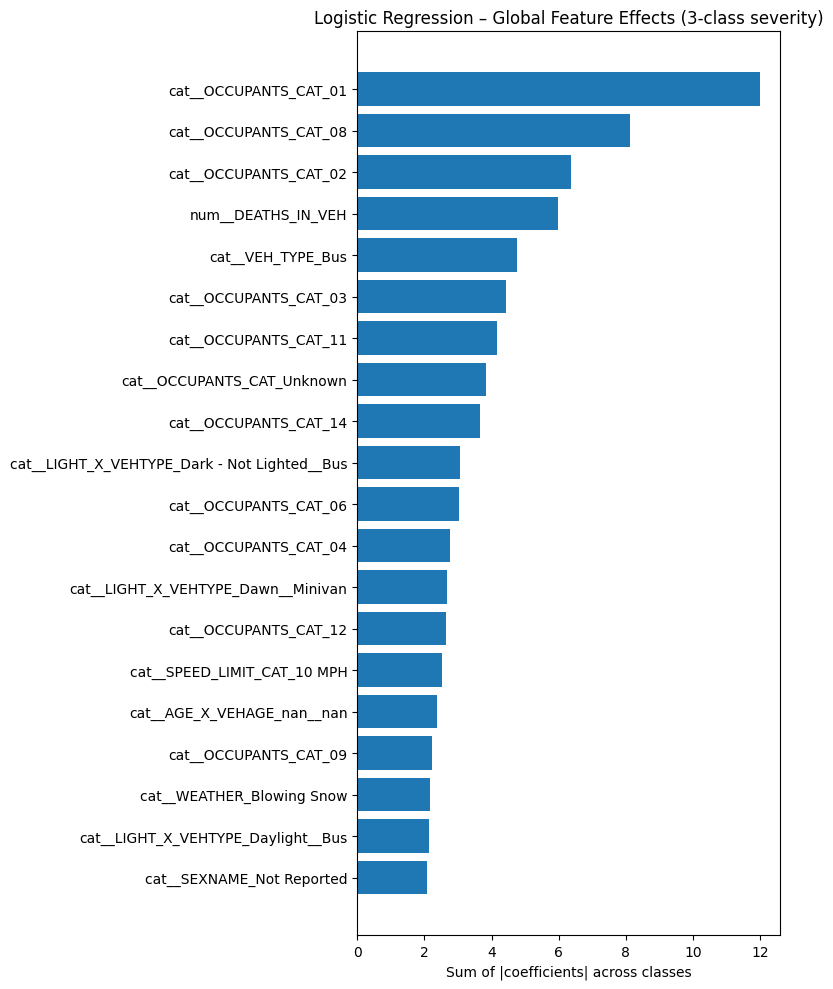

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# After fitting log_reg_clf
preprocess = log_reg_clf.named_steps["preprocess"]
log_model = log_reg_clf.named_steps["clf"]

feature_names = preprocess.get_feature_names_out()
coefs = log_model.coef_          # shape: (n_classes, n_features)

coef_df = pd.DataFrame(
    coefs.T,
    index=feature_names,
    columns=[f"class_{c}" for c in log_model.classes_]
)

# Global importance = sum of |coeff| across classes
coef_df["abs_sum"] = coef_df.abs().sum(axis=1)

coef_df_sorted = coef_df.sort_values("abs_sum", ascending=False)

# Look at the top 20
top_n = 20
top_coef = coef_df_sorted.head(top_n)

plt.figure(figsize=(8, 10))
plt.barh(top_coef.index, top_coef["abs_sum"])
plt.gca().invert_yaxis()
plt.title("Logistic Regression – Global Feature Effects (3-class severity)")
plt.xlabel("Sum of |coefficients| across classes")
plt.tight_layout()
plt.show()


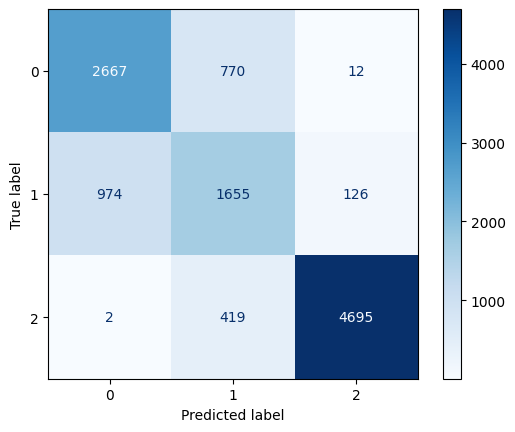

In [23]:
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.show()

# 7. Random Forest model (for SHAP & interactions)

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=50,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=42
    ))
])

rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.73      0.77      0.75      3449
           1       0.59      0.60      0.59      2755
           2       0.97      0.93      0.95      5116

    accuracy                           0.80     11320
   macro avg       0.76      0.77      0.76     11320
weighted avg       0.80      0.80      0.80     11320



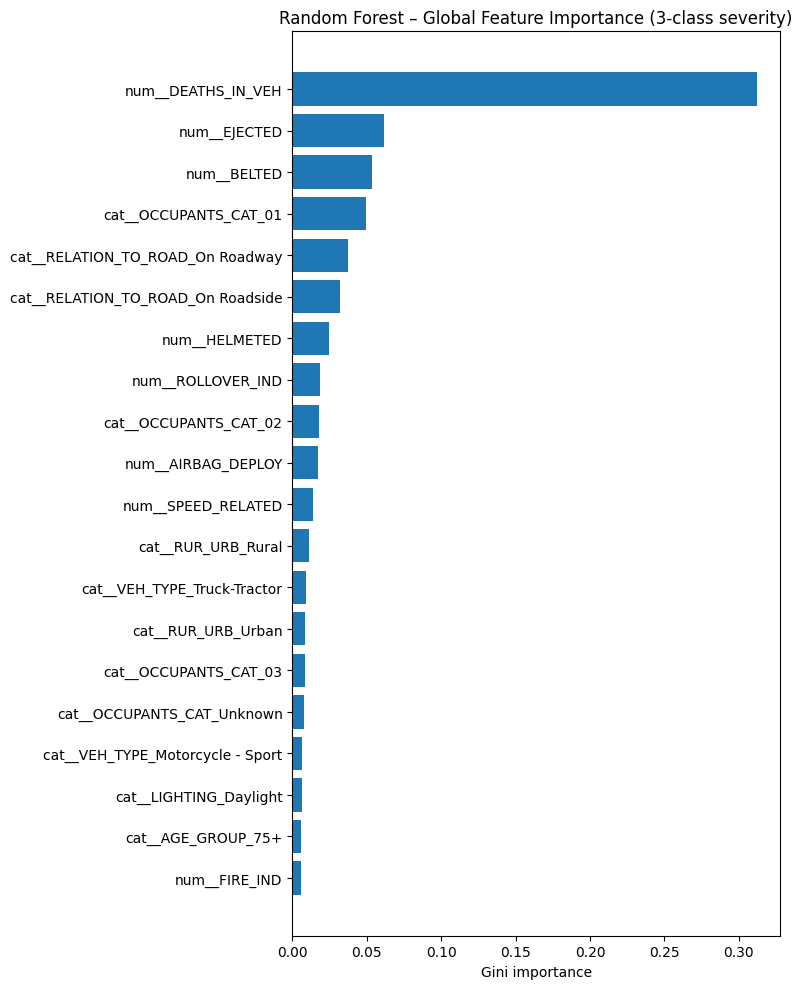

In [25]:
preprocess = rf_clf.named_steps["preprocess"]
rf_model = rf_clf.named_steps["clf"]

feature_names = preprocess.get_feature_names_out()
importances = rf_model.feature_importances_

import pandas as pd
import matplotlib.pyplot as plt

fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

top_n = 20
top_fi = fi_df.head(top_n)

plt.figure(figsize=(8, 10))
plt.barh(top_fi["feature"], top_fi["importance"])
plt.gca().invert_yaxis()
plt.title("Random Forest – Global Feature Importance (3-class severity)")
plt.xlabel("Gini importance")
plt.tight_layout()
plt.show()


# Global feature importance by group (Driver vs Vehicle vs Environment)

In [26]:
driver_features = [
    "AGE_GROUP", "SEXNAME", "BELTED", "HELMETED", "AIRBAG_DEPLOY",
    "EJECTED", "EXTRICATED", "ALCOHOL_INV", "DRUGS_INV",
    "LIC_STATUS_SIMPLE", "HAS_PREV_DWI", "HAS_PREV_SPD", "HAS_PREV_ACC",
]

vehicle_features = [
    "VEH_TYPE", "VEH_AGE_GROUP", "ROLLOVER_IND", "DEFORMED_SEVERE",
    "FIRE_IND", "SPEED_RELATED", "OCCUPANTS_CAT", "DEATHS_IN_VEH",
]

environment_features = [
    "LIGHTING", "WEATHER", "RUR_URB", "FUNC_SYS", "ROUTE_TYPE",
    "SPEED_LIMIT_CAT", "HOUR_BUCKET", "INTERSECTION_TYPE",
    "RELATION_TO_ROAD", "WORK_ZONE",
]

interaction_features = [
    "AGE_X_VEHAGE", "LIGHT_X_VEHTYPE",
]

feature_group_map = {}
for f in driver_features:
    feature_group_map[f] = "Driver"
for f in vehicle_features:
    feature_group_map[f] = "Vehicle"
for f in environment_features:
    feature_group_map[f] = "Environment"
for f in interaction_features:
    feature_group_map[f] = "Interaction"


In [27]:
preprocess = rf_clf.named_steps["preprocess"]
rf_model = rf_clf.named_steps["clf"]

feature_names = preprocess.get_feature_names_out()
importances = rf_model.feature_importances_

fi_df = pd.DataFrame({
    "feature_transformed": feature_names,
    "importance": importances
})

base_features = driver_features + vehicle_features + environment_features + interaction_features

def get_base_feature(trans_name):
    # numeric → "num__BELTED"
    if trans_name.startswith("num__"):
        return trans_name.split("__", 1)[1]
    # categorical → "cat__LIGHTING_Daylight"
    if trans_name.startswith("cat__"):
        remainder = trans_name.split("__", 1)[1]
        # find which original feature this belongs to
        for bf in base_features:
            if remainder.startswith(bf):
                return bf
    return None

fi_df["base_feature"] = fi_df["feature_transformed"].apply(get_base_feature)
fi_df.dropna(subset=["base_feature"], inplace=True)

# aggregate importance to base feature
base_importance = (
    fi_df.groupby("base_feature")["importance"]
    .sum()
    .reset_index()
)


In [28]:
base_importance["group"] = base_importance["base_feature"].map(feature_group_map)

group_importance = (
    base_importance
    .groupby("group")["importance"]
    .sum()
    .reset_index()
    .sort_values("importance", ascending=False)
)

group_importance


,group,importance
3,Vehicle,0.498917
1,Environment,0.218707
0,Driver,0.200485
2,Interaction,0.081891


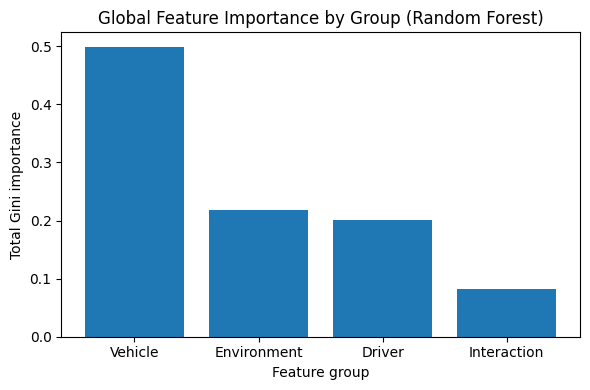

In [29]:
plt.figure(figsize=(6, 4))
plt.bar(group_importance["group"], group_importance["importance"])
plt.title("Global Feature Importance by Group (Random Forest)")
plt.ylabel("Total Gini importance")
plt.xlabel("Feature group")
plt.tight_layout()
plt.show()


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Get transformed feature names and coefficients ---
preprocess = log_reg_clf.named_steps["preprocess"]
log_model = log_reg_clf.named_steps["clf"]

feature_names = preprocess.get_feature_names_out()
coefs = log_model.coef_          # shape: (n_classes, n_features)

# coefs_df: one row per transformed feature, one column per class
coef_df = pd.DataFrame(
    coefs.T,
    index=feature_names,
    columns=[f"class_{c}" for c in log_model.classes_]
)

# global importance for each transformed feature = sum |coef| across classes
coef_df["abs_sum"] = coef_df.abs().sum(axis=1)

coef_df.reset_index(inplace=True)
coef_df.rename(columns={"index": "feature_transformed"}, inplace=True)

# base_features & feature_group_map already defined earlier
# (driver_features, vehicle_features, environment_features, interaction_features)

def get_base_feature(trans_name):
    if trans_name.startswith("num__"):
        return trans_name.split("__", 1)[1]
    if trans_name.startswith("cat__"):
        remainder = trans_name.split("__", 1)[1]
        for bf in base_features:
            if remainder.startswith(bf):
                return bf
    return None

coef_df["base_feature"] = coef_df["feature_transformed"].apply(get_base_feature)
coef_df = coef_df.dropna(subset=["base_feature"])

# --- 2. Aggregate to base feature ---
base_importance_lr = (
    coef_df.groupby("base_feature")["abs_sum"]
    .sum()
    .reset_index()
)

# Map to groups
base_importance_lr["group"] = base_importance_lr["base_feature"].map(feature_group_map)

group_importance_lr = (
    base_importance_lr
    .groupby("group")["abs_sum"]
    .sum()
    .reset_index()
    .sort_values("abs_sum", ascending=False)
)

print(group_importance_lr)



         group     abs_sum
2  Interaction  194.055166
3      Vehicle  119.696868
1  Environment   76.841800
0       Driver   14.412527


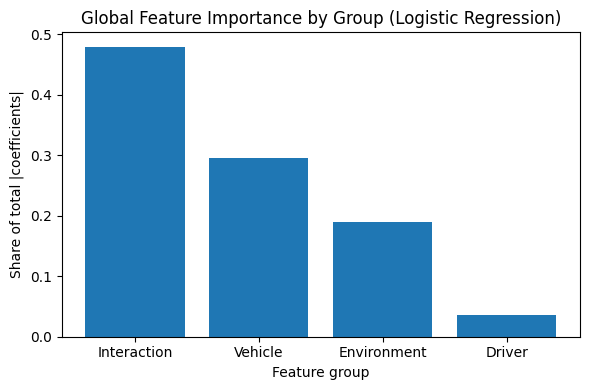

In [31]:
group_importance_lr["norm"] = (
    group_importance_lr["abs_sum"] /
    group_importance_lr["abs_sum"].sum()
)

plt.figure(figsize=(6, 4))
plt.bar(group_importance_lr["group"], group_importance_lr["norm"])
plt.title("Global Feature Importance by Group (Logistic Regression)")
plt.ylabel("Share of total |coefficients|")
plt.xlabel("Feature group")
plt.tight_layout()
plt.show()


In [32]:
from sklearn.metrics import classification_report

def fit_and_report(pipeline, name):
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    print(f"=== {name} ===")
    print(classification_report(y_test, y_pred))
    return pipeline


# Model 3: ExtraTrees (Extremely Randomized Trees)

In [33]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.pipeline import Pipeline

et_clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", ExtraTreesClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=50,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=42
    ))
])

et_clf = fit_and_report(et_clf, "ExtraTreesClassifier")


=== ExtraTreesClassifier ===
              precision    recall  f1-score   support

           0       0.74      0.74      0.74      3449
           1       0.57      0.59      0.58      2755
           2       0.94      0.91      0.92      5116

    accuracy                           0.78     11320
   macro avg       0.75      0.75      0.75     11320
weighted avg       0.79      0.78      0.78     11320



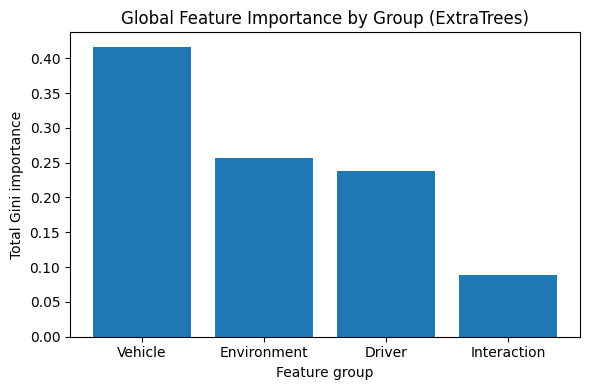

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

pre = et_clf.named_steps["preprocess"]
et_model = et_clf.named_steps["clf"]

feat_names = pre.get_feature_names_out()
importances = et_model.feature_importances_

fi_df_et = pd.DataFrame({
    "feature_transformed": feat_names,
    "importance": importances
})

fi_df_et["base_feature"] = fi_df_et["feature_transformed"].apply(get_base_feature)
fi_df_et = fi_df_et.dropna(subset=["base_feature"])

# aggregate to base feature
base_importance_et = (
    fi_df_et.groupby("base_feature")["importance"]
    .sum()
    .reset_index()
)

base_importance_et["group"] = base_importance_et["base_feature"].map(feature_group_map)

group_importance_et = (
    base_importance_et
    .groupby("group")["importance"]
    .sum()
    .reset_index()
    .sort_values("importance", ascending=False)
)

plt.figure(figsize=(6, 4))
plt.bar(group_importance_et["group"], group_importance_et["importance"])
plt.title("Global Feature Importance by Group (ExtraTrees)")
plt.ylabel("Total Gini importance")
plt.xlabel("Feature group")
plt.tight_layout()
plt.show()


# Model 4: LinearSVC (linear SVM)

In [35]:
from sklearn.svm import LinearSVC

lsvc_clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", LinearSVC(
        C=1.0,
        class_weight="balanced",
        multi_class="ovr",
        max_iter=5000
    ))
])

lsvc_clf = fit_and_report(lsvc_clf, "LinearSVC")


=== LinearSVC ===
              precision    recall  f1-score   support

           0       0.70      0.81      0.76      3449
           1       0.60      0.48      0.53      2755
           2       0.94      0.95      0.94      5116

    accuracy                           0.79     11320
   macro avg       0.75      0.75      0.74     11320
weighted avg       0.79      0.79      0.79     11320



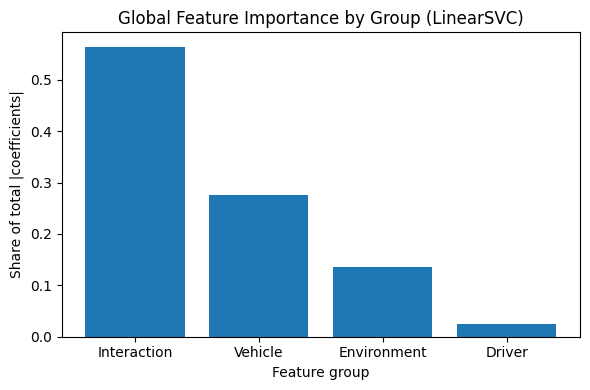

In [36]:
pre = lsvc_clf.named_steps["preprocess"]
lsvc_model = lsvc_clf.named_steps["clf"]

feat_names = pre.get_feature_names_out()
coefs = lsvc_model.coef_    # shape: (n_classes, n_features)

coef_df_lsvc = pd.DataFrame(
    coefs.T,
    index=feat_names,
    columns=[f"class_{c}" for c in lsvc_model.classes_]
)

# global importance per transformed feature
coef_df_lsvc["abs_sum"] = coef_df_lsvc.abs().sum(axis=1)
coef_df_lsvc.reset_index(inplace=True)
coef_df_lsvc.rename(columns={"index": "feature_transformed"}, inplace=True)

# map to base feature and group
coef_df_lsvc["base_feature"] = coef_df_lsvc["feature_transformed"].apply(get_base_feature)
coef_df_lsvc = coef_df_lsvc.dropna(subset=["base_feature"])

base_importance_lsvc = (
    coef_df_lsvc.groupby("base_feature")["abs_sum"]
    .sum()
    .reset_index()
)

base_importance_lsvc["group"] = base_importance_lsvc["base_feature"].map(feature_group_map)

group_importance_lsvc = (
    base_importance_lsvc
    .groupby("group")["abs_sum"]
    .sum()
    .reset_index()
    .sort_values("abs_sum", ascending=False)
)

# normalize if you want to show proportions
group_importance_lsvc["norm"] = (
    group_importance_lsvc["abs_sum"] /
    group_importance_lsvc["abs_sum"].sum()
)

plt.figure(figsize=(6, 4))
plt.bar(group_importance_lsvc["group"], group_importance_lsvc["norm"])
plt.title("Global Feature Importance by Group (LinearSVC)")
plt.ylabel("Share of total |coefficients|")
plt.xlabel("Feature group")
plt.tight_layout()
plt.show()


In [37]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, recall_score

# Assume these are already fitted Pipelines
# log_reg_clf, rf_clf, et_clf, lsvc_clf

models = {
    "Logistic Regression": log_reg_clf,
    "Random Forest":        rf_clf,
    "ExtraTrees":           et_clf,
    "Linear SVM": lsvc_clf,
}

fatal_label = 2  # adjust if your "Fatal" class is coded differently

rows = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")

    # binary vectors: 1 = fatal, 0 = not fatal
    y_true_fatal = (y_test == fatal_label).astype(int)
    y_pred_fatal = (y_pred == fatal_label).astype(int)

    fatal_rec = recall_score(y_true_fatal, y_pred_fatal, average="binary")

    rows.append({
        "Model": name,
        "Accuracy": acc,
        "Macro F1": macro_f1,
        "Fatal recall": fatal_rec,
    })

metrics_df = pd.DataFrame(rows).set_index("Model")

# Nicely formatted & colored table for the notebook
styled_metrics = (
    metrics_df
    .sort_values("Macro F1", ascending=False)
    .style
    .format("{:.3f}")
    .background_gradient(cmap="Blues", axis=0)
)

styled_metrics


,Accuracy,Macro F1,Fatal recall
Model,,,
Random Forest,0.799,0.764,0.926
Logistic Regression,0.797,0.762,0.918
ExtraTrees,0.781,0.747,0.910
Linear SVM,0.792,0.744,0.948


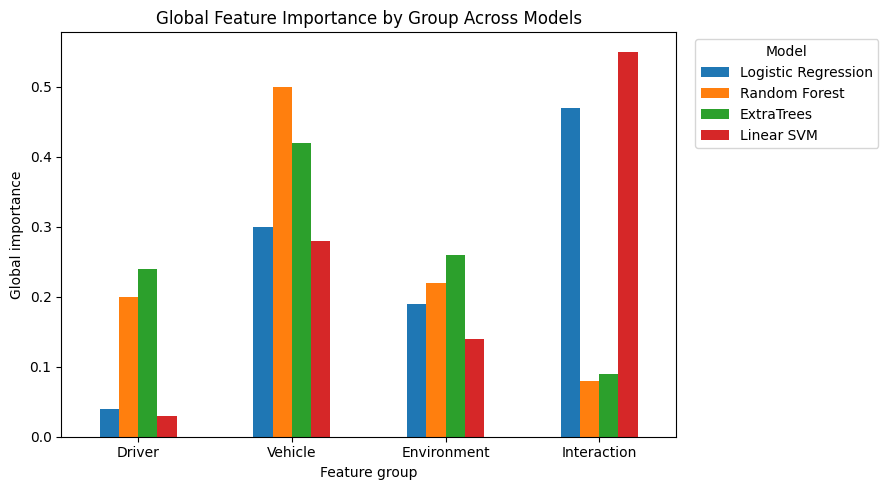

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature groups in desired order
groups = ["Driver", "Vehicle", "Environment", "Interaction"]

# Hard-coded values read from your four plots (approximate)
data = {
    "Logistic Regression": {
        "Driver":       0.04,
        "Vehicle":      0.30,
        "Environment":  0.19,
        "Interaction":  0.47,
    },
    "Random Forest": {
        "Driver":       0.20,
        "Vehicle":      0.50,
        "Environment":  0.22,
        "Interaction":  0.08,
    },
    "ExtraTrees": {
        "Driver":       0.24,
        "Vehicle":      0.42,
        "Environment":  0.26,
        "Interaction":  0.09,
    },
    "Linear SVM": {
        "Driver":       0.03,
        "Vehicle":      0.28,
        "Environment":  0.14,
        "Interaction":  0.55,
    },
}

# Build DataFrame: rows = groups, columns = models
group_importance_all = pd.DataFrame(data, index=groups)

# Plot grouped bar chart
plt.figure(figsize=(9, 5))
ax = group_importance_all.plot(kind="bar", ax=plt.gca())

ax.set_xlabel("Feature group")
ax.set_ylabel("Global importance")
ax.set_title("Global Feature Importance by Group Across Models")
ax.set_xticklabels(groups, rotation=0)
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


In [39]:
import numpy as np
import shap

# 1. Transform X_test but keep it sparse
X_test_trans = preprocess.transform(X_test)   # usually csr_matrix
feature_names = preprocess.get_feature_names_out()

# 2. Sample indices BEFORE densifying
sample_size = min(800, X_test_trans.shape[0])   # 800 is plenty for nice plots
rng = np.random.RandomState(42)
sample_idx = rng.choice(X_test_trans.shape[0], size=sample_size, replace=False)

X_shap_sparse = X_test_trans[sample_idx]
y_shap = y_test.iloc[sample_idx]

# 3. Convert only the sample to dense (if needed)
if hasattr(X_shap_sparse, "toarray"):
    X_shap = X_shap_sparse.toarray()
else:
    X_shap = X_shap_sparse

# 4. Create explainer with the fast tree-path-dependent algorithm
explainer = shap.TreeExplainer(
    rf_model,
    feature_perturbation="tree_path_dependent"  # <-- fast mode for trees
)

# 5. Compute SHAP values (disable additivity check to save extra pass)
shap_values = explainer.shap_values(X_shap, check_additivity=False)

print("shap_values shape:", shap_values.shape)  # should be (n_samples, n_features, n_classes)

# 6. Pick the Fatal class (label 2)
classes = list(rf_model.classes_)
fatal_label = 2
fatal_idx = classes.index(fatal_label)

# Take all samples, all features, Fatal class on the last axis
fatal_shap = shap_values[:, :, fatal_idx]   # shape: (n_samples, n_features)

print("fatal_shap shape:", fatal_shap.shape)  # should now be (800, 619)
print("X_shap shape:", X_shap.shape)          # (800, 619)
print("len(feature_names):", len(feature_names))  # 619

shap_values shape: (800, 619, 3)
fatal_shap shape: (800, 619)
X_shap shape: (800, 619)
len(feature_names): 619


In [ ]:
nice_feature_names = []

for fn in feature_names:
    name = fn
    # strip prefixes
    if name.startswith("num__") or name.startswith("cat__"):
        name = name.split("__", 1)[1]
    # a few manual cleanups to look nice on slides
    name = name.replace("OCCUPANTS_CAT_", "Occupants: ")
    name = name.replace("RELATION_TO_ROAD_", "Relation to road: ")
    name = name.replace("RUR_URB_", "Area: ")
    name = name.replace("VEH_TYPE_", "Vehicle type: ")
    name = name.replace("AGE_GROUP_", "Age group: ")
    name = name.replace("LIC_STATUS_SIMPLE_", "License: ")
    # add any more replacements you like
    nice_feature_names.append(name)

shap.summary_plot(
    fatal_shap,
    X_shap,
    feature_names=nice_feature_names,
    plot_type="bar",
    max_display=20
)


# A. Compute actual & predicted fatal rates by key binary factors

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 0. Assumptions to adapt ---
target_col = "inj_sev_class"   
fatal_label = 2

# df_eval should already exist; if not, build it from your modelling X/y:
df_eval = model_df.copy()

# Optional: include model-predicted fatal probability (nice for sanity-checks)
fatal_idx = list(rf_clf.named_steps["clf"].classes_).index(fatal_label)
df_eval["pred_fatal_prob"] = rf_clf.predict_proba(X)[:, fatal_idx]

def fatal_stats_by(df, feature):
    """Return count, actual fatal rate, and predicted fatal prob by feature value."""
    return (
        df.groupby(feature)
          .agg(
              count=(feature, "size"),
              actual_fatal_rate=(target_col, lambda y: np.mean(y == fatal_label)),
              pred_fatal_prob=("pred_fatal_prob", "mean")
          )
    )


In [ ]:
factor_configs = [
    {
        "col": "BELTED",                       # 0/1 numeric (0 = no belt, 1 = belt)
        "name": "Seat belt",
        "labels": {0: "Unbelted", 1: "Belted"}
    },
    {
        "col": "HELMETED",                     # for 2-wheelers, 0/1
        "name": "Helmet use",
        "labels": {0: "No helmet", 1: "Helmeted"}
    },
    {
        "col": "EJECTED",                      # 0 = not ejected, 1 = ejected
        "name": "Ejection",
        "labels": {0: "Not ejected", 1: "Ejected"}
    },
    {
        "col": "ROLLOVER_IND",                 # 0/1
        "name": "Rollover",
        "labels": {0: "No rollover", 1: "Rollover"}
    },
    {
        "col": "SPEED_RELATED",                # 0/1 from SPEEDREL
        "name": "Speed related",
        "labels": {0: "Not speed-related", 1: "Speed-related"}
    },
    {
        "col": "ALCOHOL_INV",                  # 0/1, derived from DRINKING / ALC_STATUS
        "name": "Alcohol involvement",
        "labels": {0: "No alcohol", 1: "Alcohol involved"}
    },
    {
        "col": "PREV_SPD",                     # 0/1 from PREV_SPDNAME
        "name": "Prior speeding violations",
        "labels": {0: "None", 1: "Has prior speeding"}
    },
    {
        "col": "LIC_STATUS_SIMPLE",            # e.g. 0=Valid, 1=Suspended, 2=No license/other
        "name": "License status",
        "labels": {
            0: "Valid",
            1: "Suspended",
            2: "No license/other"
        }
    },
]


In [ ]:
risk_rows = []

for cfg in factor_configs:
    col = cfg["col"]
    name = cfg["name"]
    labels = cfg["labels"]

    if col not in df_eval.columns:
        print(f"Skipping {col} (not in dataframe)")
        continue

    stats = fatal_stats_by(df_eval, col)
    # drop groups with too few samples, if you want (e.g. < 50)
    stats = stats[stats["count"] >= 50]

    if stats.empty or stats["actual_fatal_rate"].isna().all():
        print(f"Skipping {col} (no valid stats)")
        continue

    # safer = group with lowest fatal rate
    safer_val = stats["actual_fatal_rate"].idxmin()
    safer_rate = stats.loc[safer_val, "actual_fatal_rate"]

    for val, row in stats.iterrows():
        group_label = labels.get(val, str(val))
        rr = row["actual_fatal_rate"] / safer_rate if safer_rate > 0 else np.nan
        risk_rows.append({
            "Factor": name,
            "Group": group_label,
            "value": val,
            "risk_ratio": rr,
            "count": row["count"]
        })

risk_df = pd.DataFrame(risk_rows).sort_values(["Factor", "risk_ratio"], ascending=[True, False])
risk_df


In [ ]:
plt.figure(figsize=(10, 5))

x_labels = [f"{row.Factor}\n{row.Group}" for _, row in risk_df.iterrows()]
x_pos = np.arange(len(risk_df))

bars = plt.bar(x_pos, risk_df["risk_ratio"])

plt.axhline(1.0, linestyle="--", color="tab:gray")
plt.ylabel("Fatality risk vs safest group (actual)")
plt.title("How much worse? Relative fatality risk by driver & vehicle factors")
plt.xticks(x_pos, x_labels, rotation=35, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) Keep only groups that are worse than the safest group
high = risk_df[risk_df["risk_ratio"] > 1.05].copy()

# 2) For each factor, pick the group with the highest risk_ratio
high_top = (
    high.sort_values("risk_ratio", ascending=False)
        .groupby("Factor", as_index=False)
        .first()
)

# 3) Sort factors by risk for plotting
high_top = high_top.sort_values("risk_ratio")
high_top




In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# risk_df has columns: Factor, Group, risk_ratio
# Example rows: ("Seat belt", "Unbelted", 2.8), ("Helmet use", "No helmet", 2.4), ...

# Sort so the most dangerous factor is on top
plot_df = risk_df.sort_values("risk_ratio", ascending=True)  # ascending for barh bottom→top

# Build combined labels like "Seat belt: Unbelted"
y_labels = [f"{row.Factor}: {row.Group}" for _, row in plot_df.iterrows()]
x_vals = plot_df["risk_ratio"].values

plt.figure(figsize=(8, 4.5))

y_pos = np.arange(len(plot_df))
bars = plt.barh(y_pos, x_vals)

# Baseline line at 1.0 (same risk as safest group)
plt.axvline(1.0, linestyle="--", color="gray", linewidth=1)

# Add text at the end of each bar (e.g., "2.8×")
for bar, rr in zip(bars, x_vals):
    plt.text(
        bar.get_width() + 0.05,          # a bit to the right of the bar
        bar.get_y() + bar.get_height()/2,
        f"{rr:.2f}×",
        va="center",
        fontsize=9,
    )

plt.yticks(y_pos, y_labels)
plt.xlabel("Fatality risk vs safest group")
plt.title("How much worse? High-risk driver & vehicle factors\n(actual fatality rates)")
plt.xlim(0.9, max(x_vals) + 0.6)  # start close to 1.0 so differences pop

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Filter to interpretable, sufficiently common, genuinely riskier groups
avoid_words = ["other", "unknown"]
mask = ~risk_df["Group"].str.contains("|".join(avoid_words), case=False, na=False)
mask &= risk_df["risk_ratio"] > 1.05          # ignore “safe” groups ~ 1.0
mask &= risk_df["count"] >= 500              # ignore tiny categories

candidates = risk_df[mask]

# 2. For each Factor, keep the single highest-risk group
top_by_factor = (
    candidates
    .sort_values("risk_ratio", ascending=False)
    .drop_duplicates(subset="Factor", keep="first")
    .sort_values("risk_ratio")   # sort for nicer bottom→top plotting
)

top_by_factor

labels = [f"{f}: {g}" for f, g in zip(top_by_factor["Factor"],
                                      top_by_factor["Group"])]
values = top_by_factor["risk_ratio"].values

y_pos = np.arange(len(top_by_factor))

plt.figure(figsize=(8, 4.5))

# Use a qualitative colormap for distinct colours
cmap = plt.get_cmap("tab10")
colors = [cmap(i % 10) for i in range(len(top_by_factor))]

bars = plt.barh(y_pos, values, color=colors)

# Baseline at 1.0 (same risk as safest group)
plt.axvline(1.0, linestyle="--", color="gray", linewidth=1)

# Label each bar with its multiplier (e.g. "2.85×")
for bar, rr in zip(bars, values):
    plt.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{rr:.2f}×",
        va="center",
        fontsize=9,
    )

plt.yticks(y_pos, labels)
plt.xlabel("Fatality risk vs safest group")
plt.title("How much worse? Top high-risk driver & vehicle factors\n(actual fatality rates)")
plt.xlim(0.9, values.max() + 0.6)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Words we don't want in the *bad* group labels
avoid_words = ["other", "unknown"]

rows = []

for factor, df_sub in risk_df.groupby("Factor"):
    # Sort groups for this factor by risk ratio (worst first)
    df_sub = df_sub.sort_values("risk_ratio", ascending=False)

    # Take the single worst group for this factor
    worst = df_sub.iloc[0]

    grp_label = str(worst["Group"]).lower()

    # Apply your filters to the *worst* group
    if worst["risk_ratio"] <= 1.05:
        continue  # not really riskier than baseline

    if worst["count"] < 500:
        continue  # too rare to be reliable

    if any(w in grp_label for w in avoid_words):
        continue  # skip "other"/"unknown" etc.

    rows.append(worst)

# Build DataFrame of chosen factor–group pairs
top_by_factor = (
    pd.DataFrame(rows)
      .sort_values("risk_ratio")   # sort for bottom→top plotting
)

top_by_factor
labels = [f"{f}: {g}" for f, g in zip(top_by_factor["Factor"],
                                      top_by_factor["Group"])]
values = top_by_factor["risk_ratio"].values
y_pos = np.arange(len(top_by_factor))

plt.figure(figsize=(8, 4.5))

cmap = plt.get_cmap("tab10")
colors = [cmap(i % 10) for i in range(len(top_by_factor))]

bars = plt.barh(y_pos, values, color=colors)

# Baseline at 1.0 (same risk as safest group)
plt.axvline(1.0, linestyle="--", color="gray", linewidth=1)

# Label each bar with its multiplier (e.g. "2.85×")
for bar, rr in zip(bars, values):
    plt.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{rr:.2f}×",
        va="center",
        fontsize=9,
    )

plt.yticks(y_pos, labels)
plt.xlabel("Fatality risk vs safest group")
plt.title("How much worse? Top high-risk driver & vehicle factors\n(actual fatality rates)")
plt.xlim(0.9, values.max() + 0.6)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Pick the same five features (order = from your plot)
rf_features = [
    "num__EJECTED",
    "num__BELTED",
    "num__HELMETED",
    "num__ROLLOVER_IND",
    "num__SPEED_RELATED",
]

nice_labels = [
    "Ejection: Ejected",
    "Seat belt: Unbelted",
    "Helmet use: Helmeted",
    "Rollover: Yes/No",
    "Speed related: Yes",
]

# 2. Compute mean |SHAP| for each of these features (fatal class)
# fatal_shap: SHAP values for fatal class, shape [n_samples, n_features]
# feature_names: list/array of transformed feature names
feat_to_idx = {f: i for i, f in enumerate(feature_names)}

imp_vals = []
for f in rf_features:
    idx = feat_to_idx[f]
    imp_vals.append(np.abs(fatal_shap[:, idx]).mean())
imp_vals = np.array(imp_vals)

# 3. Sort by importance (smallest at bottom, largest at top)
order = np.argsort(imp_vals)
imp_vals_sorted = imp_vals[order]
labels_sorted = [nice_labels[i] for i in order]

# 4. Plot: colored, with grid + value labels
colors = ["#d73027", "#fc8d59", "#91bfdb", "#4575b4", "#fee090"]  # distinct colors
colors_sorted = [colors[i] for i in order]

plt.figure(figsize=(6, 3.8))

bars = plt.barh(labels_sorted, imp_vals_sorted, color=colors_sorted)

plt.xlabel("Mean |SHAP| for Fatal class")
plt.title("Model-based importance of high-risk factors\n(Random Forest, SHAP)")

# Light vertical grid to help compare magnitudes
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.gca().set_axisbelow(True)

# Add numeric labels at the end of each bar
for bar, val in zip(bars, imp_vals_sorted):
    plt.text(
        bar.get_width() * 1.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va="center",
        fontsize=8,
    )

plt.tight_layout()
plt.show()


## Insight 2 – High-risk combinations

In [ ]:
df_eval["pred_fatal_prob"] = rf_clf.predict_proba(X)[:, fatal_idx]

pivot_age_veh = (
    df_eval
    .groupby(["AGE_GROUP", "VEH_AGE_GROUP"])
    .agg(
        mean_fatal_prob=("pred_fatal_prob", "mean"),
        count=("pred_fatal_prob", "size")
    )
    .reset_index()
    .pivot(index="AGE_GROUP", columns="VEH_AGE_GROUP", values="mean_fatal_prob")
)

plt.figure(figsize=(6, 5))

# Use a reversed colormap: high values = dark, low values = light
plt.imshow(
    pivot_age_veh,
    aspect="auto",
    cmap="viridis_r",        # <- key change
    interpolation="nearest"
)

plt.colorbar(label="Predicted fatal probability")
plt.xticks(range(len(pivot_age_veh.columns)), pivot_age_veh.columns, rotation=45)
plt.yticks(range(len(pivot_age_veh.index)), pivot_age_veh.index)
plt.xlabel("Vehicle age group")
plt.ylabel("Driver age group")
plt.title("Age × Vehicle age – fatal risk heatmap")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---- 1. Make a copy and create grouped categories ----
df_plot = df_eval.copy()

def map_lighting(x: str):
    if isinstance(x, str):
        if "Daylight" in x:
            return "Daylight"
        if "Dark" in x and "Lighted" in x:
            return "Dark, lighted"
        if "Dark" in x and "Not Lighted" in x:
            return "Dark, no lights"
        if "Dawn" in x or "Dusk" in x:
            return "Dawn/Dusk"
    return np.nan   # everything else -> drop

def map_vehicle(x: str):
    if isinstance(x, str):
        if "Passenger Car" in x or x == "Car":
            return "Car"
        if "Sport Utility" in x or "SUV" in x:
            return "SUV"
        if "Pickup" in x:
            return "Pickup"
        if "Motorcycle" in x:
            return "Motorcycle"
        if "Truck" in x:          # Truck-tractor, single-unit, etc.
            return "Truck"
        if "Bus" in x:
            return "Bus"
    return np.nan

df_plot["LIGHTING_GRP"] = df_plot["LIGHTING"].apply(map_lighting)
df_plot["VEH_TYPE_GRP"] = df_plot["VEH_TYPE"].apply(map_vehicle)

# Drop unknown/other categories
df_plot = df_plot.dropna(subset=["LIGHTING_GRP", "VEH_TYPE_GRP"])

# ---- 2. Aggregate predicted fatal probability ----
pivot_light_veh = (
    df_plot
    .groupby(["LIGHTING_GRP", "VEH_TYPE_GRP"])
    .agg(mean_fatal_prob=("pred_fatal_prob", "mean"),
         count=("pred_fatal_prob", "size"))
    .reset_index()
    .pivot(index="LIGHTING_GRP", columns="VEH_TYPE_GRP", values="mean_fatal_prob")
)

# Optional: enforce a nice logical order
pivot_light_veh = pivot_light_veh.reindex(
    index=["Daylight", "Dark, lighted", "Dark, no lights", "Dawn/Dusk"],
    columns=["Car", "SUV", "Pickup", "Motorcycle", "Truck", "Bus"]
)

# 🔧 NEW: drop rows/cols that are all NaN (avoids white bands)
pivot_light_veh = pivot_light_veh.dropna(how="all", axis=0)  # rows
pivot_light_veh = pivot_light_veh.dropna(how="all", axis=1)  # columns

# ---- 3. Plot cleaner heatmap ----
plt.figure(figsize=(7, 4.5))
plt.imshow(
    pivot_light_veh,
    aspect="auto",
    cmap="viridis_r",           # dark = higher risk
    interpolation="nearest"
)
plt.colorbar(label="Predicted fatal probability")

plt.xticks(
    range(len(pivot_light_veh.columns)),
    pivot_light_veh.columns,
    rotation=30,
    ha="right"
)
plt.yticks(range(len(pivot_light_veh.index)), pivot_light_veh.index)

plt.xlabel("Vehicle type")
plt.ylabel("Lighting condition")
plt.title("Lighting × Vehicle type – fatal risk heatmap")
plt.tight_layout()
plt.show()


# 8. SHAP explanations (global + interactions)

In [ ]:
X_test_trans = rf_clf.named_steps["preprocess"].transform(X_test)

# If it's a sparse matrix, make it dense
if hasattr(X_test_trans, "toarray"):
    X_test_trans = X_test_trans.toarray()

# Ensure numeric float dtype
X_test_trans = np.asarray(X_test_trans, dtype=np.float64)

# SHAP expects a smaller subset for performance
sample_size = min(3000, X_test_trans.shape[0])
X_test_trans_sample = X_test_trans[:sample_size]
y_test_sample = y_test.iloc[:sample_size]


rf_model = rf_clf.named_steps["clf"]

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_trans_sample)
len(shap_values)  # number of classes (e.g., 4 for 0/1/2/3)


# 8.1 Global importance (for, say, the most severe class)

In [ ]:
class_index = 3  # adjust if needed
shap.summary_plot(shap_values[class_index], X_test_trans_sample, feature_names=feature_names)

# 8.2 Interaction plots (age × vehicle age, lighting × vehicle type)

In [ ]:
for i, fname in enumerate(feature_names[:50]):
    print(i, fname)

In [ ]:
shap.dependence_plot(
    "cat__AGE_GROUP_<20",
    shap_values[class_index],
    X_test_trans_sample,
    feature_names=feature_names,
    interaction_index="cat__VEH_AGE_GROUP_20+"
)

In [ ]:
shap.dependence_plot(
    "cat__LIGHTING_Dark - lighted",
    shap_values[class_index],
    X_test_trans_sample,
    feature_names=feature_names,
    interaction_index="cat__VEH_TYPE_Passenger Car"
)

# 9. Partial Dependence Plots (PDPs) for key variables

In [ ]:
# If you want PDP on VEH_AGE (numeric), you can add it to numeric_features and preprocess, then:
PartialDependenceDisplay.from_estimator(
    rf_clf,
    X,
    features=["VEH_AGE"],
    kind="average"
)
plt.show()

In [ ]:
PartialDependenceDisplay.from_estimator(
    rf_clf,
    X,
    features=[("AGE", "VEH_AGE")],
    kind="average"
)
plt.show()